# Outlier Case Study of MLP CO2 Adsorption Predictions

Identifies MOFs that are consistently mispredicted across the 9 MLP conditions
(3 feature sets x 3 split strategies) and explains the failures structurally and via SHAP.

In [1]:
import sys, pathlib, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import shap
warnings.filterwarnings('ignore')

sys.path.insert(0, str(pathlib.Path('..').resolve()))
from src.data_utils import load_experiment

ROOT       = pathlib.Path('..').resolve()
SPLITS_DIR = ROOT / 'data' / 'splits'
MASTER     = ROOT / 'data' / 'merged' / 'hmof_merged.parquet'
MODELS_MLP = ROOT / 'models' / 'mlp'
SHAP_MLP   = ROOT / 'results' / 'mlp' / 'shap'
RESULTS    = ROOT / 'results' / 'prediction-outlier-analysis-mlp'
RESULTS.mkdir(parents=True, exist_ok=True)

TARGET_IDX  = 2          # co2_mol_kg_0.1bar
FEAT_SETS   = ['geo_all', 'rac_all', 'combined_all']
SPLITS_LIST = ['random', 'topology', 'metal']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

KeyboardInterrupt: 

### Generate per-MOF predictions for all 9 MLP conditions

In [16]:
records = []

for split in SPLITS_LIST:
    names = pd.read_parquet(
        SPLITS_DIR / f'split_{split}_test_merged.parquet', columns=['name']
    )['name'].values

    for fs in FEAT_SETS:
        model_path = MODELS_MLP / f'{fs}__{split}__optuna.joblib'

        _, X_test, _, y_test = load_experiment(split, fs)
        model = joblib.load(model_path)  # sklearn Pipeline: Imputer -> Scaler -> MLPRegressor

        y_true    = y_test[:, TARGET_IDX]
        y_pred    = model.predict(X_test)
        residual  = y_pred - y_true
        abs_error = np.abs(residual)

        for i, name in enumerate(names):
            records.append({
                'name': name, 'split': split, 'feature_set': fs,
                'y_true': y_true[i], 'y_pred': y_pred[i],
                'residual': residual[i], 'abs_error': abs_error[i],
            })

        print(f'[done] mlp/{fs}_{split}__optuna  '
              f'RMSE={np.sqrt(np.mean(residual**2)):.4f}  '
              f'n={len(names)}')

preds = pd.DataFrame(records)
preds['condition'] = preds['split'] + '__' + preds['feature_set']
preds.to_parquet(RESULTS / 'outlier_predictions_mlp.parquet', index=False)
print(f'\nSaved {len(preds):,} prediction rows covering {preds["name"].nunique():,} unique MOFs')

[done] mlp/geo_all_random__optuna  RMSE=0.3731  n=11147
[done] mlp/rac_all_random__optuna  RMSE=0.6157  n=11147
[done] mlp/combined_all_random__optuna  RMSE=0.3140  n=11147
[done] mlp/geo_all_topology__optuna  RMSE=0.3362  n=60
[done] mlp/rac_all_topology__optuna  RMSE=0.6296  n=60
[done] mlp/combined_all_topology__optuna  RMSE=0.3454  n=60
[done] mlp/geo_all_metal__optuna  RMSE=0.3709  n=29234
[done] mlp/rac_all_metal__optuna  RMSE=0.6384  n=29234
[done] mlp/combined_all_metal__optuna  RMSE=0.3680  n=29234

Saved 121,323 prediction rows covering 37,422 unique MOFs


### Flag outliers and compute persistence scores

Outlier threshold per condition: |residual| > 2 * std(abs_error) for that condition

In [3]:
thresholds = (
    preds.groupby('condition')['abs_error']
    .std()
    .mul(2)
    .rename('threshold')
)
preds = preds.join(thresholds, on='condition')
preds['is_outlier'] = preds['abs_error'] > preds['threshold']

print('Outlier rate per condition:')
print(
    preds.groupby('condition')['is_outlier']
    .mean()
    .mul(100)
    .round(1)
    .to_string()
)

Outlier rate per condition:
condition
metal__combined_all        8.6
metal__geo_all            10.6
metal__rac_all             8.4
random__combined_all       8.9
random__geo_all            8.6
random__rac_all            9.2
topology__combined_all    13.3
topology__geo_all         10.0
topology__rac_all         13.3


In [4]:
n_seen    = preds.groupby('name')['condition'].count()
n_outlier = preds[preds['is_outlier']].groupby('name')['condition'].count()
persistence = (n_outlier / n_seen).fillna(0).sort_values(ascending=False)

print(f'MOFs that are outliers in ALL conditions:    {(persistence == 1.0).sum()}')
print(f'MOFs that are outliers in >50% conditions:  {(persistence > 0.5).sum()}')
print(f'MOFs that are outliers in any condition:    {(persistence > 0).sum()}')
print(f'Total unique MOFs in test sets:             {len(persistence)}')

MOFs that are outliers in ALL conditions:    920
MOFs that are outliers in >50% conditions:  2893
MOFs that are outliers in any condition:    6485
Total unique MOFs in test sets:             37422


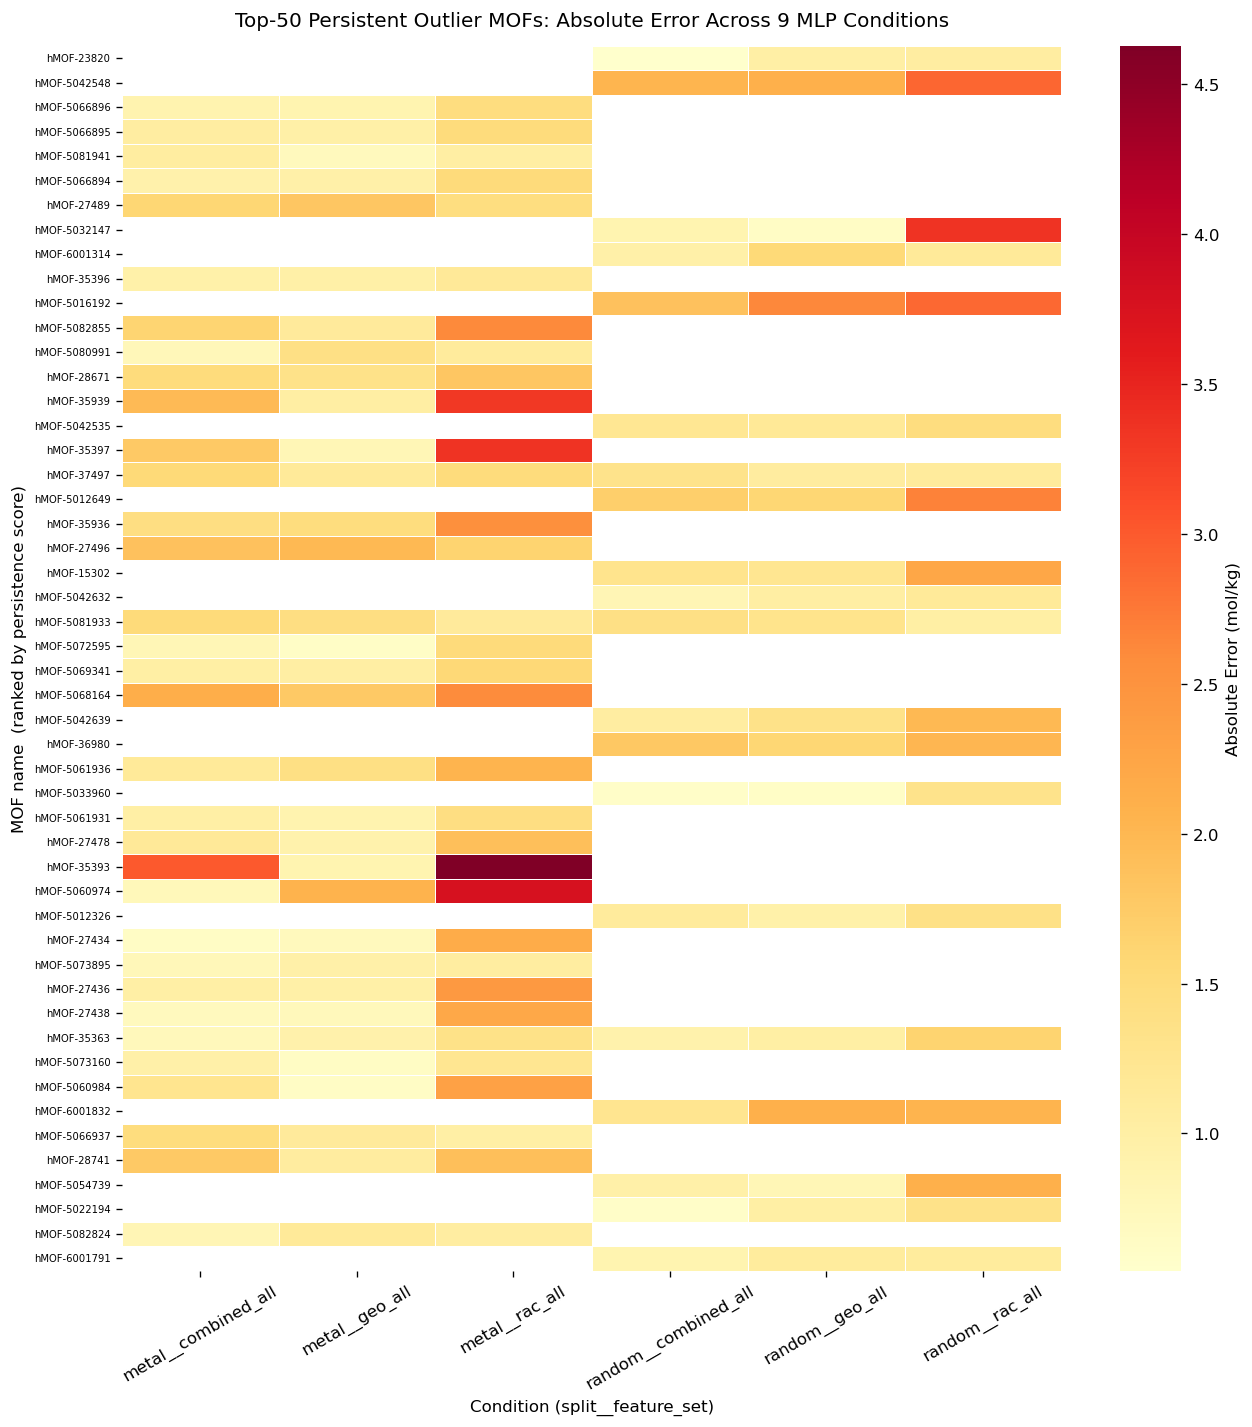

In [5]:
top50 = persistence.head(50).index

heat_df = (
    preds[preds['name'].isin(top50)]
    .pivot_table(index='name', columns='condition', values='abs_error', aggfunc='mean')
    .loc[top50]
)

fig, ax = plt.subplots(figsize=(11, 12))
sns.heatmap(
    heat_df, ax=ax, cmap='YlOrRd',
    cbar_kws={'label': 'Absolute Error (mol/kg)'},
    linewidths=0.3, linecolor='white'
)
ax.set_title('Top-50 Persistent Outlier MOFs: Absolute Error Across 9 MLP Conditions', pad=12)
ax.set_xlabel('Condition (split__feature_set)')
ax.set_ylabel('MOF name  (ranked by persistence score)')
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_heatmap_mlp.png', bbox_inches='tight')
plt.show()

### Structural characterization of persistent outliers

In [6]:
GEO_COLS = ['pld', 'lcd', 'surface_area_m2g', 'void_fraction', 'density_g_cm3']
meta = pd.read_parquet(
    MASTER,
    columns=['name', 'topology', 'metal_node'] + GEO_COLS
).set_index('name')

persistent_threshold = 0.5
top_names  = persistence[persistence >= persistent_threshold].index
meta_out   = meta.loc[meta.index.isin(top_names)]
meta_all   = meta
print(f'Characterizing {len(meta_out)} MOFs with persistence ≥ {persistent_threshold}')

Characterizing 2982 MOFs with persistence ≥ 0.5


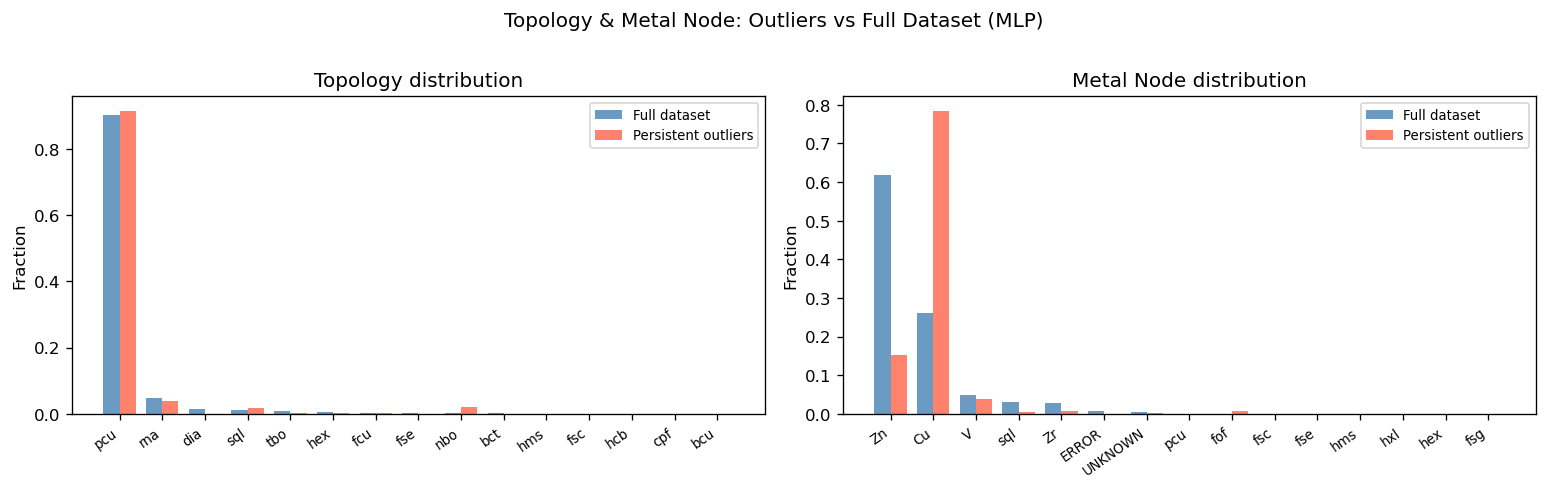

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['topology', 'metal_node'],
    ['Topology', 'Metal Node']
):
    frac_all = meta_all[col].value_counts(normalize=True).head(15)
    frac_out = meta_out[col].value_counts(normalize=True).reindex(frac_all.index, fill_value=0)

    x = np.arange(len(frac_all))
    w = 0.38
    ax.bar(x - w/2, frac_all.values, width=w, label='Full dataset', color='steelblue', alpha=0.8)
    ax.bar(x + w/2, frac_out.values, width=w, label='Persistent outliers', color='tomato', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(frac_all.index, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('Fraction')
    ax.set_title(f'{title} distribution')
    ax.legend(fontsize=8)

plt.suptitle('Topology & Metal Node: Outliers vs Full Dataset (MLP)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_structure_dist_mlp.png', bbox_inches='tight')
plt.show()

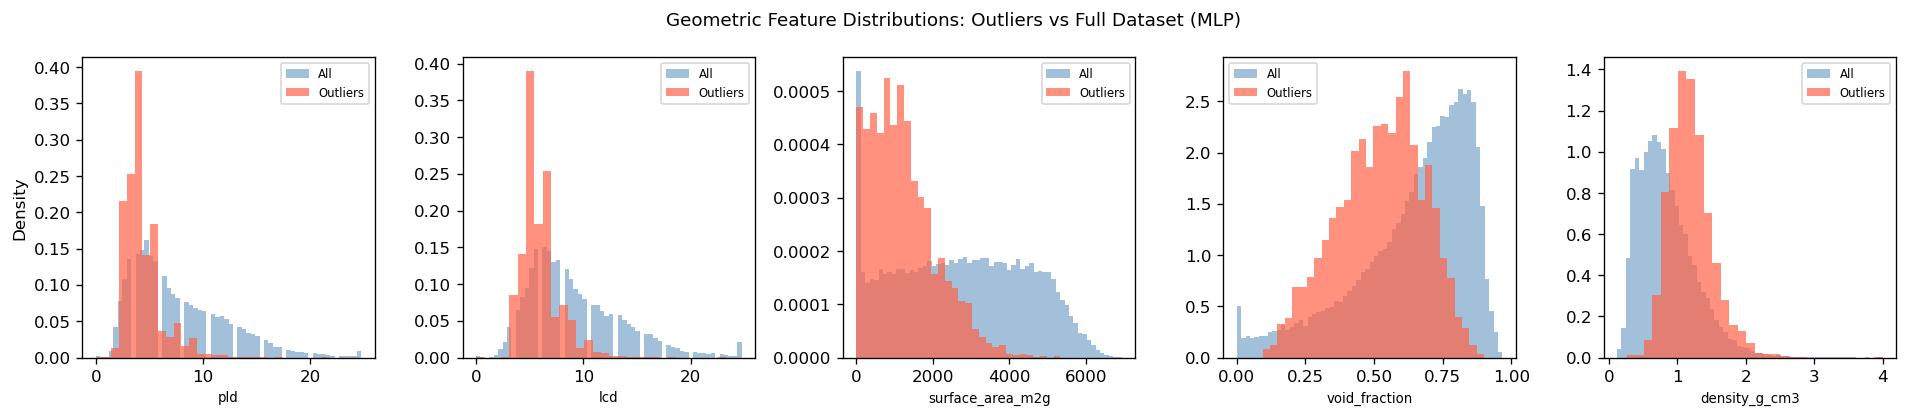

In [8]:
fig, axes = plt.subplots(1, len(GEO_COLS), figsize=(16, 3.5))

for ax, col in zip(axes, GEO_COLS):
    ax.hist(meta_all[col].dropna(), bins=60, density=True,
            color='steelblue', alpha=0.5, label='All')
    ax.hist(meta_out[col].dropna(), bins=30, density=True,
            color='tomato', alpha=0.7, label='Outliers')
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('Density' if ax == axes[0] else '')
    ax.legend(fontsize=7)

plt.suptitle('Geometric Feature Distributions: Outliers vs Full Dataset (MLP)', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_geo_dist_mlp.png', bbox_inches='tight')
plt.show()

### Descriptor-type dissection -> classify each MOF by which feature sets expose it as an outlier

- geo_only: outlier under `geo_all` but NOT `combined_all` → RAC features fix it
- always: outlier under all three → model-agnostic failure
- rac_only: outlier under `rac_all` but NOT `combined_all`

In [9]:
outlier_any_split = (
    preds[preds['is_outlier']]
    .groupby(['name', 'feature_set'])
    .size()
    .gt(0)
    .unstack(fill_value=False)
)
for fs in FEAT_SETS:
    if fs not in outlier_any_split.columns:
        outlier_any_split[fs] = False

geo = outlier_any_split['geo_all']
rac = outlier_any_split['rac_all']
comb = outlier_any_split['combined_all']

categories = {
    'Geo only\n(RAC fixes it)':    (geo & ~comb).sum(),
    'RAC only\n(geo fixes it)':    (rac & ~comb).sum(),
    'Always outlier\n(all 3)':     (geo & rac & comb).sum(),
    'Combined only':               (~geo & ~rac & comb).sum(),
    'Never outlier':               (~geo & ~rac & ~comb).sum(),
}

print('MOF counts by outlier category:')
for k, v in categories.items():
    print(f'  {k.replace(chr(10), " "):35s}: {v}')

MOF counts by outlier category:
  Geo only (RAC fixes it)            : 1843
  RAC only (geo fixes it)            : 1675
  Always outlier (all 3)             : 967
  Combined only                      : 737
  Never outlier                      : 0


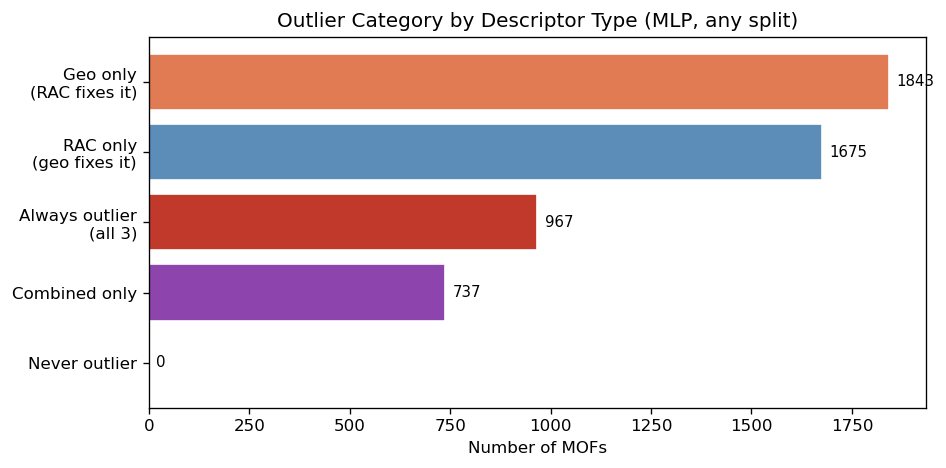

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#e07b54', '#5b8db8', '#c0392b', '#8e44ad', '#95a5a6']
labels = list(categories.keys())
values = list(categories.values())

bars = ax.barh(labels, values, color=colors, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_width() + max(values)*0.01, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of MOFs')
ax.set_title('Outlier Category by Descriptor Type (MLP, any split)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS / 'outlier_descriptor_categories_mlp.png', bbox_inches='tight')
plt.show()

In [11]:
geo_only_mask = geo & ~comb
geo_only_mofs = outlier_any_split[geo_only_mask].index.tolist()
print(f'"Geo only" outliers (RAC/combined fixes them): {len(geo_only_mofs)}')

geo_only_preds = preds[preds['name'].isin(geo_only_mofs)].copy()
error_by_fs = (
    geo_only_preds
    .groupby(['name', 'feature_set'])['abs_error']
    .mean()
    .unstack()
    [FEAT_SETS]
)
error_by_fs['improvement'] = error_by_fs['geo_all'] - error_by_fs['combined_all']
print('\nTop 10 geo-only outliers by error improvement (geo_all → combined_all):')
print(error_by_fs.sort_values('improvement', ascending=False).head(10).round(4).to_string())

"Geo only" outliers (RAC/combined fixes them): 1843

Top 10 geo-only outliers by error improvement (geo_all → combined_all):
feature_set   geo_all  rac_all  combined_all  improvement
name                                                     
hMOF-5080034   2.4262   0.8226        0.1065       2.3198
hMOF-5080301   2.5964   0.1251        0.3502       2.2462
hMOF-5082564   2.3463   0.4167        0.1382       2.2080
hMOF-36566     2.0754   1.2545        0.0424       2.0331
hMOF-5064956   2.3480   0.8050        0.4083       1.9397
hMOF-6001327   2.1647   2.9136        0.2379       1.9269
hMOF-5060969   1.9759   1.4009        0.0561       1.9198
hMOF-5063118   2.1153   3.1701        0.2163       1.8990
hMOF-28929     2.1208   0.3547        0.2296       1.8913
hMOF-5082321   2.2701   1.8285        0.4249       1.8453


### SHAP case study for selected outliers

Pick the top 3 "geo only" outliers (biggest error improvement when adding RAC features) and show what SHAP says about each.

In [12]:
SPLIT_CS = 'random'

# Restrict to MOFs that actually appear in the case-study split's test set,
# otherwise the SHAP cell can't look them up.
cs_test_names = set(pd.read_parquet(
    SPLITS_DIR / f'split_{SPLIT_CS}_test_merged.parquet', columns=['name']
)['name'].values)

case_mofs = (
    error_by_fs[error_by_fs.index.isin(cs_test_names)]
    .sort_values('improvement', ascending=False)
    .head(3)
    .index
    .tolist()
)
print(f'Case-study MOFs (in {SPLIT_CS} test set):', case_mofs)

Case-study MOFs (in random test set): ['hMOF-6001327', 'hMOF-5081405', 'hMOF-5073190']


In [13]:
def _row_match(X_explain, target_row):
    #NaN-aware row matching: returns (index, diff) of best match in X_explain
    A = np.where(np.isnan(X_explain), 0.0, X_explain)
    b = np.where(np.isnan(target_row), 0.0, target_row)
    nan_a = np.isnan(X_explain)
    nan_b = np.isnan(target_row)
    # Penalise rows where NaN patterns differ
    pattern_mismatch = (nan_a != nan_b).sum(axis=1).astype(float)
    diffs = np.abs(A - b).sum(axis=1) + pattern_mismatch * 1e6
    best = int(diffs.argmin())
    return best, diffs[best]


def get_shap_for_mof(mof_name, split, feature_set, n_bg=200):
    """Compute SHAP waterfall data for one MOF using the optuna MLP pipeline.

    Tries to reuse cached .npz SHAP file; falls back to PermutationExplainer on `model.predict`.
    Returns (shap_values_1d, feature_values_1d, feature_names, expected_value) or None.
    """
    model_path = MODELS_MLP / f'{feature_set}__{split}__optuna.joblib'
    model = joblib.load(model_path)

    X_train, X_test, _, _ = load_experiment(split, feature_set)
    names_test = pd.read_parquet(
        SPLITS_DIR / f'split_{split}_test_merged.parquet', columns=['name']
    )['name'].values

    feat_cfg = json.loads((ROOT / 'data' / 'merged' / 'feature_selection.json').read_text())
    feature_names = feat_cfg['feature_sets'][feature_set]

    mof_idx = np.where(names_test == mof_name)[0]
    if len(mof_idx) == 0:
        return None
    mof_idx = mof_idx[0]

    # Try cached .npz
    npz_path = SHAP_MLP / f'{feature_set}__{split}.npz'
    if npz_path.exists():
        cached = np.load(npz_path, allow_pickle=True)
        X_explain = cached['X_explain']
        shap_vals = cached['shap_values']
        exp_val   = float(cached['expected_value'])
        best, diff = _row_match(X_explain, X_test[mof_idx])
        if diff < 1e-3:
            return shap_vals[best], X_explain[best], feature_names, exp_val

    # Fallback: compute fresh on the full pipeline
    bg = shap.sample(X_train, n_bg, random_state=42)
    explainer = shap.PermutationExplainer(model.predict, bg)
    explanation = explainer(X_test[[mof_idx]])
    return explanation.values[0], X_test[mof_idx], feature_names, float(explanation.base_values[0])

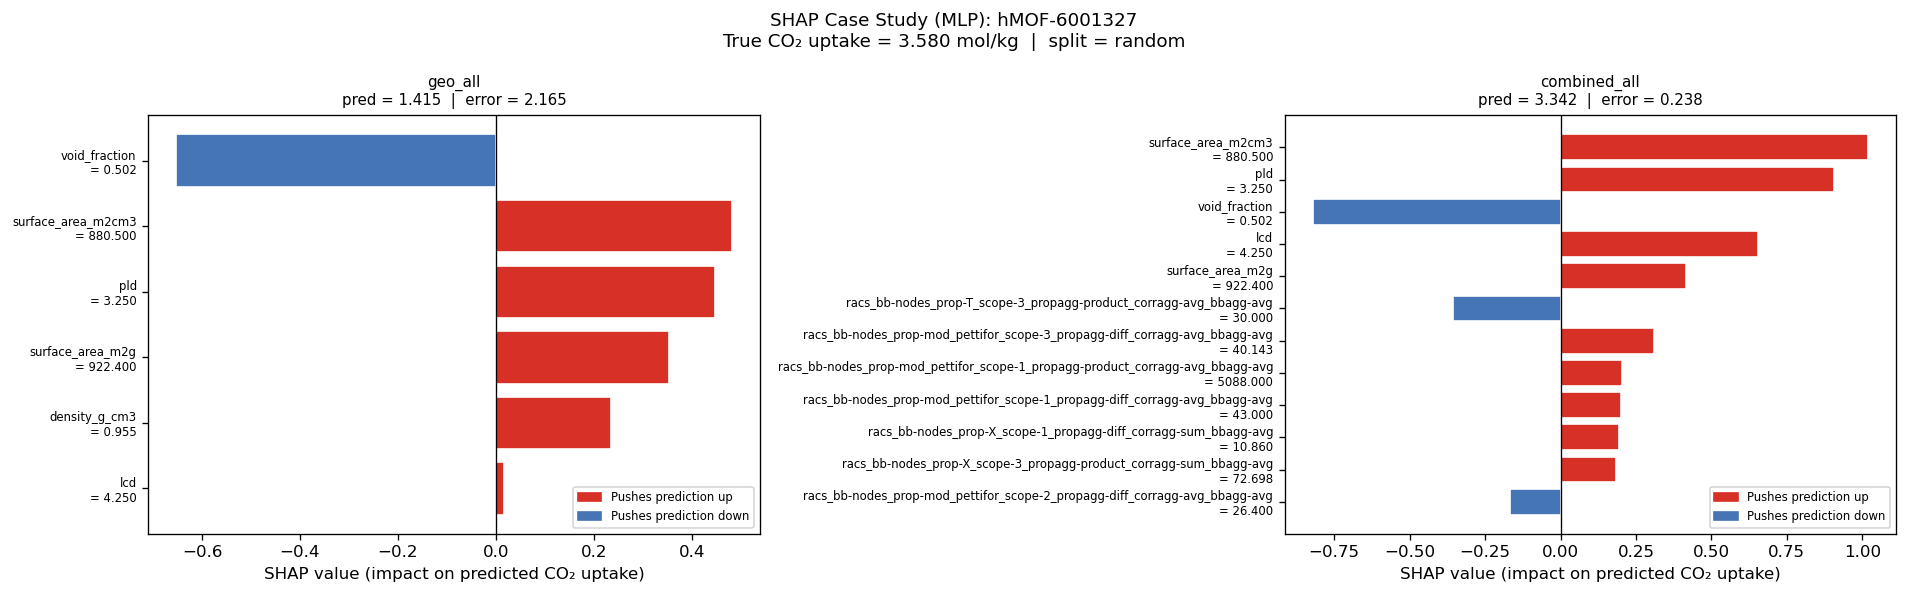

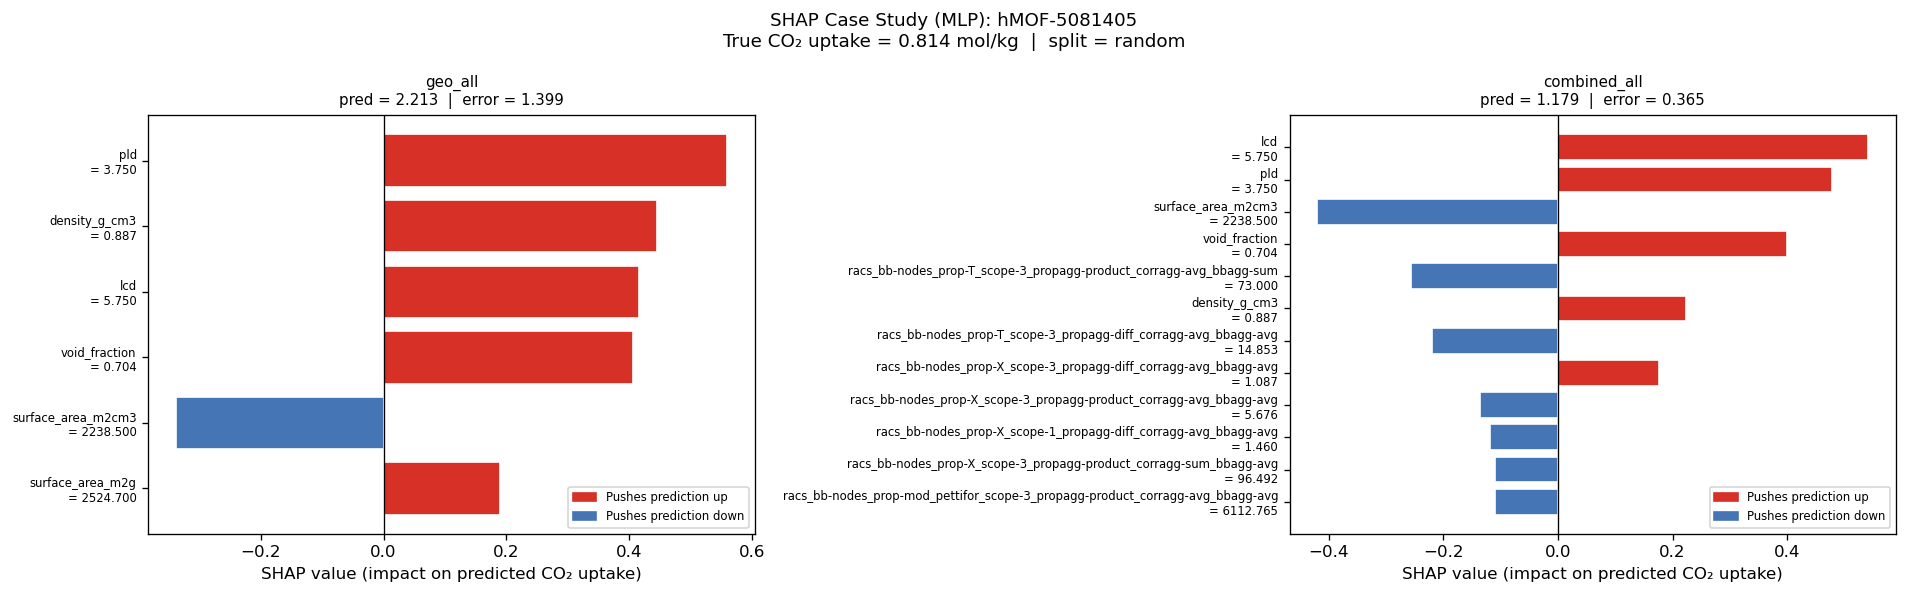

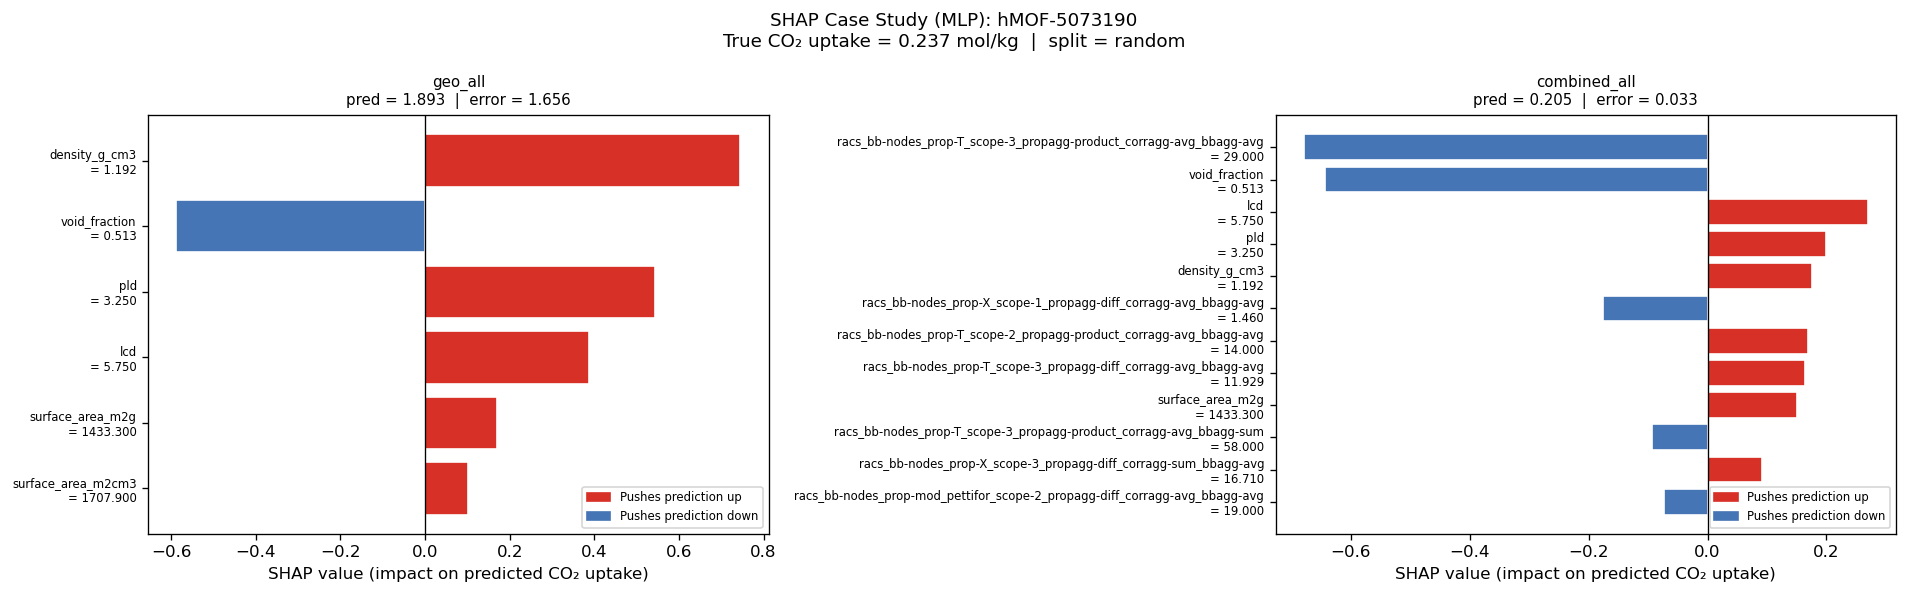

In [14]:
for mof in case_mofs:
    row = preds[(preds['name'] == mof) & (preds['split'] == SPLIT_CS)]
    y_true_val = row['y_true'].iloc[0] if len(row) else float('nan')

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(
        f'SHAP Case Study (MLP): {mof}\n'
        f'True CO₂ uptake = {y_true_val:.3f} mol/kg  |  split = {SPLIT_CS}',
        fontsize=11
    )

    for ax, fs in zip(axes, ['geo_all', 'combined_all']):
        result = get_shap_for_mof(mof, SPLIT_CS, fs)
        if result is None:
            ax.text(0.5, 0.5, f'MOF not in {SPLIT_CS} test set', transform=ax.transAxes, ha='center')
            ax.set_title(fs)
            continue

        sv, xv, fn, ev = result
        pred_val = ev + sv.sum()

        mof_row_pred = preds[(preds['name'] == mof) &
                             (preds['split'] == SPLIT_CS) &
                             (preds['feature_set'] == fs)]
        pred_display = mof_row_pred['y_pred'].iloc[0] if len(mof_row_pred) else pred_val
        err_display  = mof_row_pred['abs_error'].iloc[0] if len(mof_row_pred) else abs(pred_val - y_true_val)

        N = min(12, len(sv))
        order = np.argsort(np.abs(sv))[::-1][:N]
        sv_top = sv[order]
        fn_top = [fn[i] for i in order]
        xv_top = xv[order]

        colors = ['#d73027' if v > 0 else '#4575b4' for v in sv_top]
        y_pos  = np.arange(N)
        ax.barh(y_pos, sv_top, color=colors, edgecolor='white')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(
            [f'{n}\n= {v:.3f}' for n, v in zip(fn_top, xv_top)],
            fontsize=7
        )
        ax.invert_yaxis()
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('SHAP value (impact on predicted CO₂ uptake)')
        ax.set_title(
            f'{fs}\npred = {pred_display:.3f}  |  error = {err_display:.3f}',
            fontsize=9
        )
        red_patch  = mpatches.Patch(color='#d73027', label='Pushes prediction up')
        blue_patch = mpatches.Patch(color='#4575b4', label='Pushes prediction down')
        ax.legend(handles=[red_patch, blue_patch], fontsize=7, loc='lower right')

    plt.tight_layout()
    safe_name = mof.replace('/', '_').replace(' ', '_')
    plt.savefig(RESULTS / f'outlier_shap_{safe_name}_mlp.png', bbox_inches='tight')
    plt.show()